Importing libraries

In [2]:
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

Checking GPU

In [24]:
print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(
        f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )
else:
    device = torch.device("cpu")
    print("WARNING: CUDA is not available. Running on CPU.")

Python Version: 3.13.5
PyTorch Version: 2.11.0+cu126
CUDA Available: True
GPU Device Name: NVIDIA GeForce RTX 4050 Laptop GPU
Total VRAM: 6.44 GB


Weights & Biases Initialization

In [4]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ADMIN\_netrc.
wandb: Currently logged in as: tvhd (tvhd-vietnamese-german-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Importing data

In [5]:
csv_path = "D:\\sentiment and sarcasm analysis\\data\\raw\\IMDB Dataset.csv"
if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Could not find the dataset at {csv_path}. Please check your folder structure!"
    )

print(f"Reading dataset from: {csv_path}...")
df = pd.read_csv(csv_path)
print(f"Original Dataset Shape: {df.shape}")

Reading dataset from: D:\sentiment and sarcasm analysis\data\raw\IMDB Dataset.csv...
Original Dataset Shape: (50000, 2)


Inspect the first few records

In [17]:
print("\n[First 3 Rows of Data]:")
print(df.head(3))


[First 3 Rows of Data]:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive


Check for missing values

In [18]:
print("\n[Missing Values Check]:")
print(df.isnull().sum())


[Missing Values Check]:
review       0
sentiment    0
dtype: int64


Check class balance in the raw dataset

In [19]:
print("\n[Class Balance Summary]:")
print(df["sentiment"].value_counts())


[Class Balance Summary]:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


Calculate word count per review on the raw strings

In [21]:
print("\nCalculating review word lengths...")
df["word_count"] = df["review"].apply(lambda x: len(str(x).split()))
print("\n[Review Word Count Statistics]:")
print(df["word_count"].describe())


Calculating review word lengths...

[Review Word Count Statistics]:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


Generate plots to visualize balance and word distribution

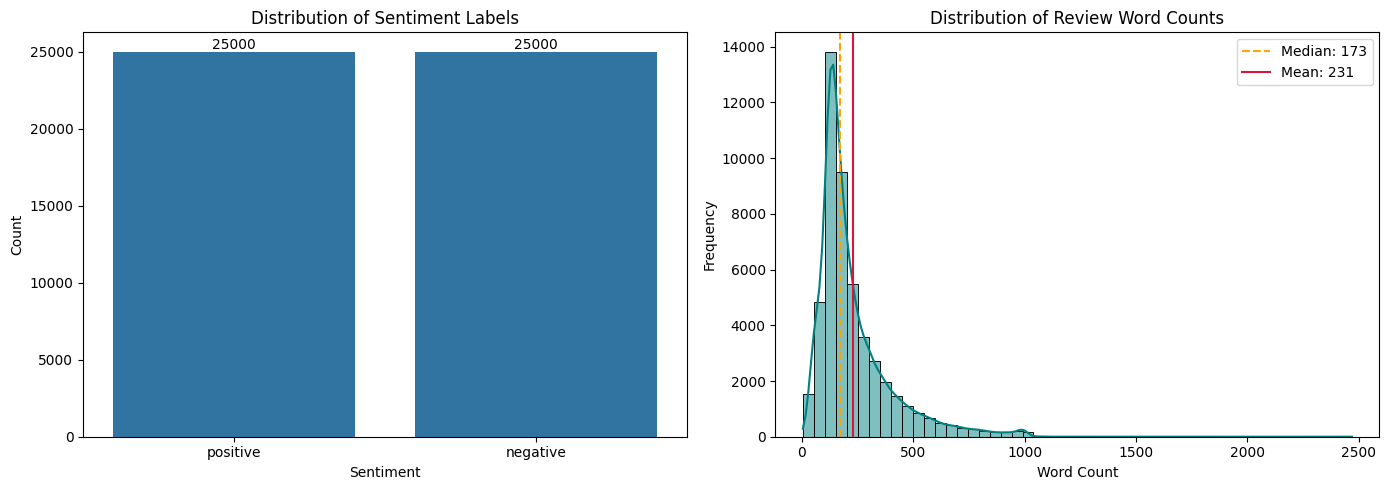

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Left: Sentiment Distribution
sns.countplot(x="sentiment", data=df, ax=axes[0], order=["positive", "negative"])
axes[0].set_title("Distribution of Sentiment Labels")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container)

# Plot Right: Review Length Histogram
sns.histplot(df["word_count"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].axvline(
    df["word_count"].median(),
    color="orange",
    linestyle="--",
    label=f"Median: {df['word_count'].median():.0f}",
)
axes[1].axvline(
    df["word_count"].mean(),
    color="crimson",
    linestyle="-",
    label=f"Mean: {df['word_count'].mean():.0f}",
)
axes[1].set_title("Distribution of Review Word Counts")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

Check the 95th percentile

In [24]:
p95 = df["word_count"].quantile(0.95)
print(f"\n[EDA Insight]: 95% of all raw reviews are under {p95:.0f} words.")
print(
    "We can use this metric later to choose our max sentence sequence length for BERT."
)


[EDA Insight]: 95% of all raw reviews are under 590 words.
We can use this metric later to choose our max sentence sequence length for BERT.


Target Text Cleaning Function

In [7]:
def clean_movie_review(text):

    # Strip HTML line breaks (<br />, <br>) left behind by web scrapers
    clean_text = re.sub(r'<br\s*/?>', ' ', text)

    # Collapse multiple consecutive spaces down into a single space
    clean_text = re.sub(r'\s+', ' ', clean_text)
    return clean_text.strip()

print("Cleaning text data...")
df['review_clean'] = df['review'].apply(clean_movie_review)

Cleaning text data...


Convert text targets to numbers: positive -> 1, negative -> 0

In [8]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

Data Split


In [9]:
train_df, val_test_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['label']
)

In [10]:
val_df, test_df = train_test_split(
    val_test_df, 
    test_size=0.50, 
    random_state=42, 
    stratify=val_test_df['label']
)

Verify exact lengths for data split

In [11]:
print(f"Train Dataset Size:      {len(train_df)} rows ({len(train_df)/len(df)*100:.0f}%)")
print(f"Validation Dataset Size: {len(val_df)} rows ({len(val_df)/len(df)*100:.0f}%)")
print(f"Test Dataset Size:       {len(test_df)} rows ({len(test_df)/len(df)*100:.0f}%)")

print("\nTrain Split Class Balance Check:")
print(train_df['sentiment'].value_counts(normalize=True))

Train Dataset Size:      40000 rows (80%)
Validation Dataset Size: 5000 rows (10%)
Test Dataset Size:       5000 rows (10%)

Train Split Class Balance Check:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


Initialize a new Weights & Biases run for the baseline model

In [31]:
run = wandb.init(
    project="sentiment-sarcasm-analysis",
    name="tfidf_logistic_regression",
    config={
        "vectorizer": "TF-IDF",
        "max_features": 10000,
        "ngram_range": (1, 2),
        "model": "Logistic Regression",
        "C": 1.0,
        "split": "80-10-10"
    }
)

Extract Text Features using TF-IDF

In [12]:
print("Vectorizing text data with TF-IDF...")
# We use unigrams and bigrams, limited to the top 10,000 most important words
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit and transform the training text; transform validation and test text
X_train = vectorizer.fit_transform(train_df['review_clean'])
X_val = vectorizer.transform(val_df['review_clean'])
X_test = vectorizer.transform(test_df['review_clean'])

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

Vectorizing text data with TF-IDF...


Train Logistic Regression

In [16]:
print("Training Logistic Regression classifier...")
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

Training Logistic Regression classifier...


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Predict and Evaluate on Validation Split

In [17]:
val_preds = baseline_model.predict(X_val)

val_accuracy = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average='macro')

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Macro F1: {val_f1:.4f}")
print(classification_report(y_val, val_preds, target_names=['negative', 'positive']))

Validation Accuracy: 0.9002
Validation Macro F1: 0.9002
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      2500
    positive       0.89      0.91      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



Log metrics and a Confusion Matrix to WandB

In [36]:
wandb.log({"conf_mat": wandb.plot.confusion_matrix(
    probs=None,
    y_true=y_val,
    preds=val_preds,
    class_names=['negative', 'positive']
)})
run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


wandb: WARNING Artifact "run-uvukdj7w-conf_mat_table" already exists with the same content. No new version will be created.


BERT TOKENIZATION & DATASET PREPARATION

In [46]:
from transformers import BertTokenizer
import torch
from torch.utils.data import Dataset
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import numpy as np
from accelerate.state import PartialState

Initialize the official pre-trained BERT tokenizer

In [19]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Define a custom PyTorch Dataset class for text samples

In [25]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Calling the tokenizer directly avoids encode_plus version compatibility issues
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,        # Adds '[CLS]' and '[SEP]'
            max_length=self.max_len,
            padding='max_length',           # Pads short reviews out to 512
            truncation=True,                # Truncates long reviews down to 512
            return_attention_mask=True,     # Generates the attention mask matrix
            return_tensors='pt',            # Return native PyTorch tensors
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

Create instances of our custom dataset for Train and Validation splits

In [21]:
train_dataset = IMDBDataset(train_df['review_clean'], train_df['label'], tokenizer, max_len=512)
val_dataset = IMDBDataset(val_df['review_clean'], val_df['label'], tokenizer, max_len=512)

print(f"Train dataset wrapper complete: {len(train_dataset)} samples.")
print(f"Validation dataset wrapper complete: {len(val_dataset)} samples.")

Train dataset wrapper complete: 40000 samples.
Validation dataset wrapper complete: 5000 samples.


In [22]:
sample = train_dataset[0]
print("\n=== Tokenization Sanity Check ===")
print(f"Shape of Input IDs:      {sample['input_ids'].shape}")
print(f"Shape of Attention Mask: {sample['attention_mask'].shape}")
print(f"Target Label Scalar:     {sample['labels'].item()}")


=== Tokenization Sanity Check ===
Shape of Input IDs:      torch.Size([512])
Shape of Attention Mask: torch.Size([512])
Target Label Scalar:     1


Load Pre-trained BERT with a binary classification head

In [47]:
PartialState._reset_state()
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)
model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10951.76it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Define Compute Metrics function for validation evaluation

In [48]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

Configure Training Arguments optimized for 6GB VRAM

In [49]:
training_args = TrainingArguments(
    output_dir="../models/bert_sentiment_fixed",
    num_train_epochs=1,  # 1 epoch is plenty to see if it's learning correctly!
    # VRAM Tuning
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    fp16=True,
    # Explicit Optimization Settings
    learning_rate=2e-5,  # Classic safe learning rate for fine-tuning BERT
    weight_decay=0.01,  # Helps stabilize weight updates
    warmup_ratio=0.1,  # Gradually increases learning rate at start
    # Routine
    eval_strategy="steps",
    eval_steps=400,  # Evaluate every 400 steps so we can watch it improve!
    logging_steps=100,
    report_to="wandb",
    run_name="bert_fixed_sentiment_run",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Instantiate the Hugging Face Trainer API wrapper

In [50]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Start Fine-Tuning

In [51]:
print("\nLaunching fine-tuning pipeline on GPU...")
trainer.train()

print("\nSaving final fine-tuned BERT model parameters...")
model.save_pretrained('../models/bert_sentiment')
tokenizer.save_pretrained('../models/bert_sentiment')


Launching fine-tuning pipeline on GPU...


Step,Training Loss,Validation Loss,Accuracy,F1 Macro
400,0.534676,0.231456,0.912800,0.912799
800,0.508704,0.187629,0.932800,0.932789
1200,0.418870,0.224750,0.912600,0.912368
1600,0.392924,0.191078,0.932000,0.931995
2000,0.315518,0.198900,0.935200,0.935161
2400,0.350566,0.177531,0.940800,0.940794
2500,0.397866,0.173298,0.940000,0.939997


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]



Saving final fine-tuned BERT model parameters...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]


('../models/bert_sentiment\\tokenizer_config.json',
 '../models/bert_sentiment\\tokenizer.json')

Prepare Test Data for BERT

In [53]:
test_dataset = IMDBDataset(
    test_df["review_clean"], test_df["label"], tokenizer, max_len=512
)

Generate Predictions from Fine-Tuned BERT

In [54]:
print("Extracting predictions from BERT model...")
bert_predictions_output = trainer.predict(test_dataset)
bert_logits = bert_predictions_output.predictions
bert_preds = np.argmax(bert_logits, axis=-1)
y_test = test_df["label"].values

Extracting predictions from BERT model...


Calculate Global Metrics

In [55]:
bert_acc = accuracy_score(y_test, bert_preds)
bert_f1 = f1_score(y_test, bert_preds, average="macro")
# Re-calculate Baseline predictions on the exact same test subset
baseline_test_preds = baseline_model.predict(X_test)
base_acc = accuracy_score(y_test, baseline_test_preds)
base_f1 = f1_score(y_test, baseline_test_preds, average="macro")

Comparative Performance Summary Table

In [56]:
print("\n" + "=" * 50)
print(f"{'MODEL PERFORMANCE COMPARISON ON TEST SET':^50}")
print("=" * 50)
print(f"Classical ML Baseline (TF-IDF + LogReg):")
print(f"  - Test Accuracy : {base_acc*100:.2f}%")
print(f"  - Macro F1-Score: {base_f1*100:.2f}%")
print("-" * 50)
print(f"Fine-Tuned BERT Model:")
print(f"  - Test Accuracy : {bert_acc*100:.2f}%")
print(f"  - Macro F1-Score: {bert_f1*100:.2f}%")
print("=" * 50)


     MODEL PERFORMANCE COMPARISON ON TEST SET     
Classical ML Baseline (TF-IDF + LogReg):
  - Test Accuracy : 90.28%
  - Macro F1-Score: 90.28%
--------------------------------------------------
Fine-Tuned BERT Model:
  - Test Accuracy : 94.34%
  - Macro F1-Score: 94.34%


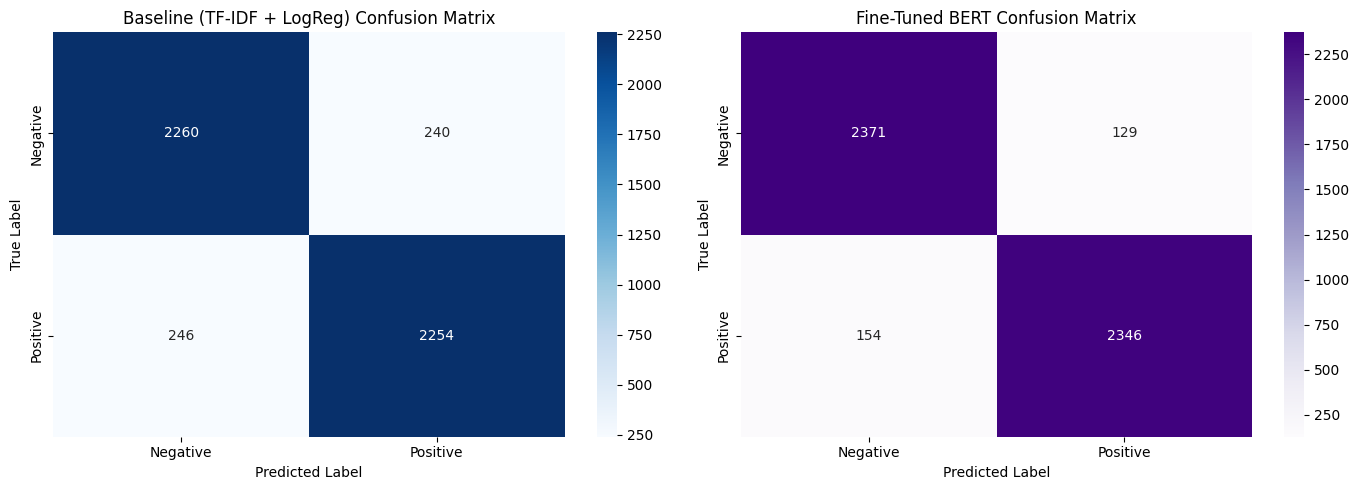

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Matrix
cm_base = confusion_matrix(y_test, baseline_test_preds)
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
axes[0].set_title("Baseline (TF-IDF + LogReg) Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# BERT Matrix
cm_bert = confusion_matrix(y_test, bert_preds)
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=axes[1],
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
axes[1].set_title("Fine-Tuned BERT Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

Recalculate predictions mapping to ensure clean matching arrays

In [60]:
test_df = test_df.copy()
test_df["baseline_pred"] = baseline_test_preds
test_df["bert_pred"] = bert_preds

Filter rows: True Label matches BERT, but does NOT match Baseline

In [61]:
bert_win_df = test_df[
    (test_df["label"] == test_df["bert_pred"])
    & (test_df["label"] != test_df["baseline_pred"])
]

print(
    f"Found {len(bert_win_df)} cases out of 5,000 where BERT corrected the baseline!"
)

Found 332 cases out of 5,000 where BERT corrected the baseline!


In [62]:
print("\n=== Spotlighting 3 Key Linguistic Edge Cases ===")
samples = bert_win_df.sample(n=min(3, len(bert_win_df)), random_state=42)

for idx, row in enumerate(samples.itertuples(), 1):
    true_sentiment = "POSITIVE" if row.label == 1 else "NEGATIVE"
    print(f"\n[Sample {idx}]")
    print(f"True Sentiment: {true_sentiment}")
    print(f"Text Content:   {row.review[:350]}...")
    print("-" * 60)


=== Spotlighting 3 Key Linguistic Edge Cases ===

[Sample 1]
True Sentiment: POSITIVE
Text Content:   People say that this film is a 'typical teen horror movie'... well it's a horror movie with a teenage girl in it.. what do you expect! It's a good film, I counted 3 actual screams in the audience whilst the film was on and it was a very jumpy scary film. I wasn't bored in the film at any point and I was even on the edge of my seat at one point. The...
------------------------------------------------------------

[Sample 2]
True Sentiment: POSITIVE
Text Content:   In Cinema Retro magazine #2,it is revealed that Mark Lester's voice was actually dubbed by a 20 year old female, Kathe Green. Although Leste was considered perfect for the title role, director Carol Reed was not at all pleased with his singing abilities. The secret was revealed by on a 2004 UK documentary titled "Oliver! After They Were Famous". Gr...
------------------------------------------------------------

[Sample 3]
Tr